In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier, RandomForestRegressor


from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, GridSearchCV

In [2]:
train_df = pd.read_csv('/kaggle/input/playground-series-s5e10/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e10/test.csv')

In [3]:
train_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [4]:
train_df.groupby(['weather'], as_index=False)['accident_risk'].mean()

,weather,accident_risk
0,clear,0.310060
1,foggy,0.386305
2,rainy,0.361494


In [5]:
train_df.groupby(['speed_limit'], as_index=False)['num_reported_accidents'].mean()

,speed_limit,num_reported_accidents
0,25,1.175672
1,35,1.161384
2,45,1.159799
3,60,1.199673
4,70,1.259058


In [6]:
# --- Risk Maps ---
road_risk = {
    "highway": 0.6,
    "rural": 0.4,
    "urban": 0.2
}

lighting_risk = {
    "daylight": 0.1,
    "dim": 0.4,
    "night": 0.8
}

weather_risk = {
    "clear": 0.1,
    "foggy": 0.5,
    "rainy": 0.8
}

# --- Risk Functions ---

def curvature_risk(curv):
    if curv < 5: return 0.1
    elif curv < 15: return 0.4
    elif curv < 30: return 0.7
    else: return 1.0

def speed_risk(speed):
    if speed < 40: return 0.2
    elif speed < 80: return 0.5
    else: return 0.9

# --- Slip Calculation Function ---

def calculate_slip(row):
    r_road = road_risk.get(row['road_type'], 0.5)
    r_curve = curvature_risk(row['curvature'])
    r_speed = speed_risk(row['speed_limit'])
    r_light = lighting_risk.get(row['lighting'], 0.4)
    r_weather = weather_risk.get(row['weather'], 0.4)

    score = (
        r_road * 0.25 +
        r_curve * 0.20 +
        r_speed * 0.25 +
        r_light * 0.10 +
        r_weather * 0.20
    )

    return round(score, 3)

# --- Apply to DataFrame ---
train_df['slipping_chances'] = train_df.apply(calculate_slip, axis=1)

train_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,slipping_chances
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,0.290
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,0.150
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,0.305
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,0.420
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,0.355


In [7]:
train_df.groupby(['slipping_chances'], as_index=False)['accident_risk'].mean().sort_values(by="accident_risk")

,slipping_chances,accident_risk
2,0.200,0.166826
6,0.250,0.166926
0,0.150,0.169064
1,0.180,0.171579
11,0.280,0.218498
5,0.230,0.219190
16,0.310,0.257175
27,0.370,0.257868
21,0.340,0.258274
36,0.420,0.259772


In [8]:
test_df['slipping_chances'] = test_df.apply(calculate_slip, axis=1)

test_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,slipping_chances
0,517754,highway,2,0.34,45,night,clear,True,True,afternoon,True,True,1,0.395
1,517755,urban,3,0.04,45,dim,foggy,True,False,afternoon,True,False,0,0.335
2,517756,urban,2,0.59,35,dim,clear,True,False,afternoon,True,True,1,0.180
3,517757,rural,4,0.95,35,daylight,rainy,False,False,afternoon,False,False,2,0.340
4,517758,highway,2,0.86,35,daylight,clear,True,False,evening,False,True,3,0.250


In [9]:
train_df.head(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,slipping_chances
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,0.290
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,0.150
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,0.305
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,0.420
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,0.355
5,5,highway,3,0.54,70,night,foggy,True,False,morning,False,True,0,0.61,0.475
6,6,highway,1,0.04,45,night,foggy,False,True,morning,True,False,2,0.20,0.475
7,7,highway,2,0.33,45,daylight,clear,False,True,evening,False,True,0,0.16,0.325
8,8,rural,3,0.63,25,dim,clear,True,False,evening,True,True,2,0.18,0.230
9,9,urban,4,0.38,45,dim,clear,True,True,afternoon,True,True,2,0.15,0.255


In [10]:
# Weather, Road Sign, Public Road, Time_of_day, School Season, Num_reported_accidents

# Computing visibility factor

# Clear + True -> 0.31 + 0.2 = 0.55 (0.31 + 0.3524 = 0.6624)
# Clear + False -> 0.31 + 0.15 = 0.46 (0.31 + 0.3522 = 0.6622)

# Foggy + True -> 0.38 + 0.2 = 0.58 
# Foggy + False -> 0.38 + 0.15 = 0.43 

# Rainy + True -> 0.36 + 0.2 = 0.56 
# Rainy + False -> 0.36 + 0.15 = 0.44 

train_df.groupby(['weather'], as_index=False)['accident_risk'].mean()

,weather,accident_risk
0,clear,0.310060
1,foggy,0.386305
2,rainy,0.361494


In [11]:
train_df.groupby(['public_road'], as_index=False)['accident_risk'].mean()

,public_road,accident_risk
0,False,0.347190
1,True,0.357518


In [12]:
def visibility_factor(weather, road_signs_present):
    """
    Acts as a multiplier: poor visibility amplifies existing risk.
    road_signs_present is assumed boolean: True = better navigation.
    """
    
    if weather == "clear":
        return 1.0 if road_signs_present else 1.1  # small effect

    elif weather == "foggy":
        return 1.2 if road_signs_present else 1.4  # big impact

    elif weather == "rainy":
        return 1.15 if road_signs_present else 1.3

    return 1.0  # fallback


train_df["visibility_factor"] = train_df.apply(
    lambda row: visibility_factor(row["weather"], row["road_signs_present"]),
    axis=1
)

test_df["visibility_factor"] = test_df.apply(
    lambda row: visibility_factor(row["weather"], row["road_signs_present"]),
    axis=1
)



# ------------------------------
# 3️⃣ Final Combined Accident Risk
# ------------------------------

# ------------------------------
# Final Combined Accident Risk for TRAIN
# ------------------------------
train_df["final_risk"] = (
    train_df["slipping_chances"] * train_df["visibility_factor"]
).round(3)

train_df["final_risk"] = train_df["final_risk"].clip(0, 1)


# ------------------------------
# Final Combined Accident Risk for TEST
# ------------------------------
test_df["final_risk"] = (
    test_df["slipping_chances"] * test_df["visibility_factor"]
).round(3)

test_df["final_risk"] = test_df["final_risk"].clip(0, 1)


In [13]:
train_df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,slipping_chances,visibility_factor,final_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,0.290,1.30,0.377
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,0.150,1.00,0.150
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,0.305,1.10,0.336
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,0.420,1.15,0.483
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,0.355,1.40,0.497


In [14]:
train_df.groupby(['visibility_factor'], as_index=False)['accident_risk'].mean().sort_values(by="accident_risk")

,visibility_factor,accident_risk
1,1.10,0.310018
0,1.00,0.310103
4,1.30,0.361042
2,1.15,0.361938
3,1.20,0.386112
5,1.40,0.386495


In [15]:
train_df.groupby(['visibility_factor'], as_index=False)['accident_risk'].mean().sort_values(by="accident_risk")

,visibility_factor,accident_risk
1,1.10,0.310018
0,1.00,0.310103
4,1.30,0.361042
2,1.15,0.361938
3,1.20,0.386112
5,1.40,0.386495


In [16]:
train_df.head(10)

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk,slipping_chances,visibility_factor,final_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13,0.290,1.30,0.377
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35,0.150,1.00,0.150
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30,0.305,1.10,0.336
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21,0.420,1.15,0.483
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56,0.355,1.40,0.497
5,5,highway,3,0.54,70,night,foggy,True,False,morning,False,True,0,0.61,0.475,1.20,0.570
6,6,highway,1,0.04,45,night,foggy,False,True,morning,True,False,2,0.20,0.475,1.40,0.665
7,7,highway,2,0.33,45,daylight,clear,False,True,evening,False,True,0,0.16,0.325,1.10,0.358
8,8,rural,3,0.63,25,dim,clear,True,False,evening,True,True,2,0.18,0.230,1.00,0.230
9,9,urban,4,0.38,45,dim,clear,True,True,afternoon,True,True,2,0.15,0.255,1.00,0.255


In [17]:
train_df.groupby(['num_lanes'], as_index=False)['accident_risk'].mean().sort_values(by="accident_risk")

,num_lanes,accident_risk
3,4,0.347161
0,1,0.351317
1,2,0.353795
2,3,0.357308


In [18]:
ohe = OneHotEncoder(sparse_output=False)
ode = OrdinalEncoder
SI = SimpleImputer(strategy='most_frequent')

In [19]:
ode_cols = ['road_type', 'weather', 'lighting']
ohe_cols = ['time_of_day']

<Axes: >

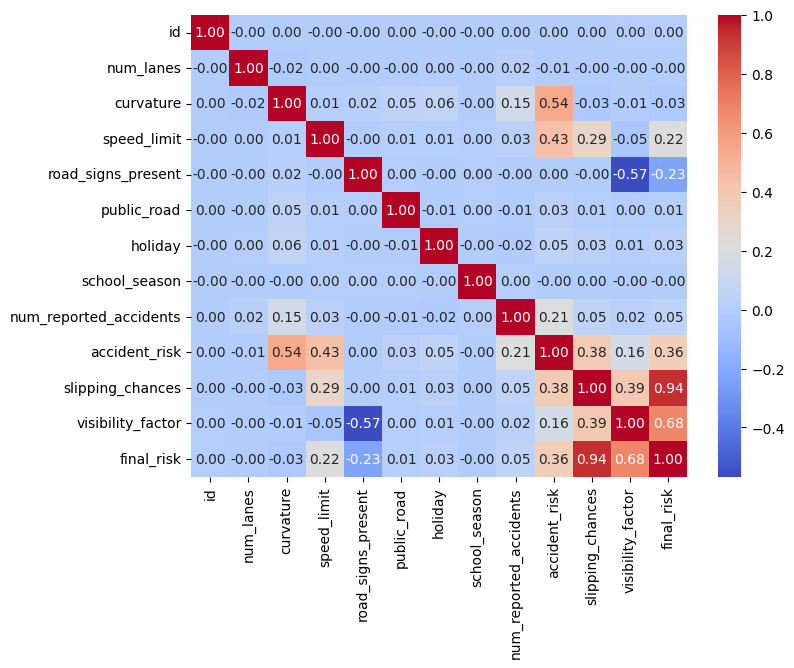

In [20]:
correlation_matrix = train_df.corr(numeric_only=True)

# Create a heatmap using Seaborn
plt.figure(figsize=(8, 6))  # Adjust the figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [21]:
X = train_df.drop([
    'accident_risk',   
    'final_risk',
    'id',           
    'num_lanes',
    'public_road',
    'holiday',
    'school_season',
    'num_reported_accidents'
], axis=1)

y = train_df['accident_risk']

X_test = test_df.drop([
    'final_risk',
    'id',
    'num_lanes',
    'public_road',
    'holiday',
    'school_season',
    'num_reported_accidents'
], axis=1)

In [22]:
numeric_cols = ['speed_limit','curvature','slipping_chances','visibility_factor']
categorical_cols = ['road_type','weather','lighting','time_of_day']

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

col_trans = ColumnTransformer([
    ('num', num_pipeline, numeric_cols),
    ('cat', cat_pipeline, categorical_cols)
], remainder='passthrough')

model = RandomForestRegressor(random_state=21)
pipefinalrfr = Pipeline([('prep', col_trans), ('model', model)])


In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=21)

In [24]:
pipefinalrfr.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['speed_limit', 'curvature',
                                                   'slipping_chances',
                                                   'visibility_factor']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['road_type', 'weather',
                                                   'lighting',
                                                   'time_of_day'])])),
                ('model', RandomForestRegressor(random_state=21))])

In [25]:
def predict_one(sample_row):
    return round(pipefinalrfr.predict(sample_row)[0], 3)


In [26]:
sample = X_valid.sample(10, random_state=21)
preds = [predict_one(pd.DataFrame([row])) for idx, row in sample.iterrows()]
truth = y_valid.loc[sample.index].values

comparison = pd.DataFrame({
    "Predicted Risk": preds,
    "Actual Risk": truth
}).reset_index(drop=True)

comparison


,Predicted Risk,Actual Risk
0,0.213,0.19
1,0.047,0.02
2,0.227,0.25
3,0.210,0.13
4,0.327,0.40
5,0.476,0.44
6,0.348,0.26
7,0.503,0.57
8,0.617,0.70
9,0.344,0.36


In [27]:
from sklearn.metrics import mean_squared_log_error
y_pred = pipefinalrfr.predict(X_valid)

rmsle = np.sqrt(mean_squared_log_error(y_valid, y_pred))

print(f"RMSLE: {rmsle:.5f}")

RMSLE: 0.04941


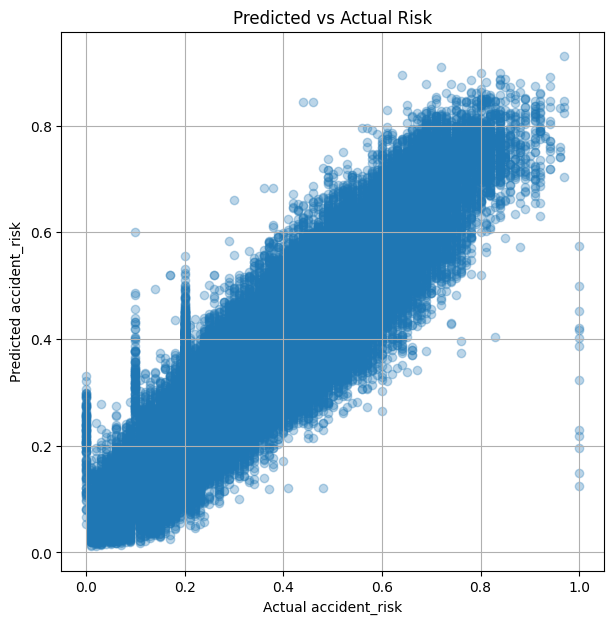

In [28]:
plt.figure(figsize=(7,7))
plt.scatter(y_valid, y_pred, alpha=0.3)
plt.xlabel("Actual accident_risk")
plt.ylabel("Predicted accident_risk")
plt.title("Predicted vs Actual Risk")
plt.grid(True)
plt.show()

In [29]:
test_predictions = pipefinalrfr.predict(X_test)

test_predictions = np.round(test_predictions, 4) 

submission = pd.DataFrame({
    "id": test_df["id"], 
    "accident_risk": test_predictions
})


submission.to_csv("submission.csv", index=False)
submission.head()

,id,accident_risk
0,517754,0.3144
1,517755,0.1195
2,517756,0.1649
3,517757,0.4346
4,517758,0.2483
